In [58]:
import torch, torchvision, numpy as np
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [59]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0, 1)
])

In [60]:
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=8, shuffle=True)

In [61]:
testset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)
test_loader = DataLoader(testset, batch_size=8, shuffle=False)

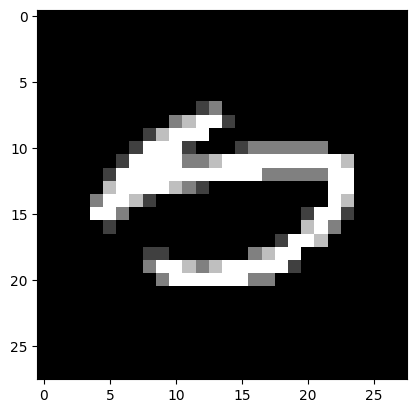

In [62]:
plt.imshow(next(iter(trainloader))[0][0][0], cmap='grey')

In [ ]:
class CNN(nn.Module):
    def __init__(self, in_l, out_f):
        super().__init__()
        self.conv1 = nn.Conv2d(in_l, 4, kernel_size=4) # обучаемые параметры - это элементы свертки/ядра
        self.pool1 = nn.AvgPool2d(2, stride=2)

        self.conv2 = nn.Conv2d(4, 10, kernel_size=4, stride=2)
        self.pool2 = nn.AvgPool2d(2, stride=2)

        self.seq = nn.Sequential(
            nn.Linear(2*2*10, 20),
            nn.ReLU(),
            nn.Linear(20, out_f)
        )

    def forward(self, x):
        # print(x.shape)
        x = self.pool1(torch.relu(self.conv1(x)))
        # print(x.shape)
        x = self.pool2(torch.relu(self.conv2(x)))
        # print(x.shape)
        x = x.view(-1, 2*2*10)
        # print(x.shape)
        x = self.seq(x)
        return x

In [64]:
from tqdm import tqdm

 33%|███▎      | 1/3 [00:15<00:31, 15.96s/it]

0 :: 0.472207023890689


 67%|██████▋   | 2/3 [00:31<00:15, 15.43s/it]

1 :: 0.20386520821850282


100%|██████████| 3/3 [00:45<00:00, 15.31s/it]

2 :: 0.16046813401292892


CNN(
  (conv1): Conv2d(1, 4, kernel_size=(4, 4), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(4, 10, kernel_size=(4, 4), stride=(2, 2))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (seq): Sequential(
    (0): Linear(in_features=40, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=10, bias=True)
  )
)

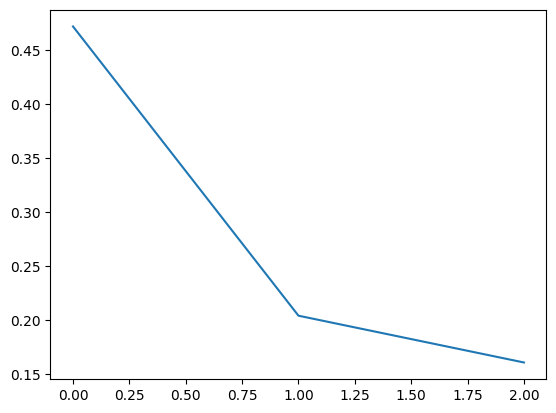

In [65]:
# net = CNN(1, 10).to(device='cuda')
net = CNN(1, 10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

def train(trainloader, model, criterion, optimizer, epoch=3):
    history_loss = []
    for e in tqdm(range(epoch)):
        e_loss = []
        for X, y in trainloader:
            y_pred = model(X)

            loss = criterion(y_pred, y)
            e_loss.append(loss.item())
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()
        print(e, '::', np.mean(e_loss))
        history_loss.append(np.mean(e_loss))
    plt.plot(history_loss)
    return model


train(trainloader, net, criterion, optimizer)

In [66]:
X, y = next(iter(test_loader))

y_pred = net(X)
print(y_pred.softmax(dim=1).argmax(dim=1),y, sep='\n')

tensor([7, 2, 1, 0, 4, 1, 4, 9])
tensor([7, 2, 1, 0, 4, 1, 4, 9])


In [67]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        y_pred = net(images)
        _, predicted = torch.max(y_pred, 1)
        
        c = (predicted.cpu().detach() == labels)
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

classes = list(range(10))
for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of     0 : 97 %
Accuracy of     1 : 98 %
Accuracy of     2 : 95 %
Accuracy of     3 : 96 %
Accuracy of     4 : 95 %
Accuracy of     5 : 94 %
Accuracy of     6 : 97 %
Accuracy of     7 : 94 %
Accuracy of     8 : 93 %
Accuracy of     9 : 97 %


#### Интересно
За какие патерны ухватилась первая свертка? Если посмотреть на ее веса, то можно увидеть закономерность с картинками!

In [ ]:
net.conv1.weight

Parameter containing:
tensor([[[[ 4.7497e-01,  2.8327e-01,  4.8756e-01,  5.1336e-01],
          [-2.6403e-01,  3.8870e-01,  4.7447e-01,  5.7902e-01],
          [-8.3431e-01, -3.2506e-01, -1.6078e-01, -2.5666e-01],
          [-1.0333e+00, -7.2728e-01, -6.0418e-01, -7.7107e-01]]],


        [[[-8.6990e-01, -2.0224e-01,  3.6414e-01,  5.0271e-01],
          [-9.2998e-01, -1.4188e-01, -1.5006e-03,  7.8483e-01],
          [-5.0296e-01, -6.7057e-02,  2.0153e-01,  5.6479e-01],
          [-2.1536e-01,  1.0113e-01,  2.2204e-01,  5.0630e-01]]],


        [[[ 5.4930e-04, -2.9988e-01,  4.5386e-02,  6.0070e-02],
          [ 3.4820e-01,  2.7417e-01,  2.5984e-01,  5.2930e-01],
          [ 3.5993e-01,  2.4434e-01,  2.2016e-02, -5.6252e-02],
          [-3.9370e-01, -4.5546e-01, -2.5690e-01,  1.7852e-01]]],


        [[[ 6.0370e-02, -3.8653e-01, -6.2118e-01, -6.8383e-01],
          [ 1.1904e-01, -2.9642e-01, -3.5603e-01, -2.9245e-01],
          [ 1.1929e-01,  1.2704e-01,  4.5122e-01,  3.6982e-01],
      

In [74]:
kop = next(iter(trainloader))[0][0]

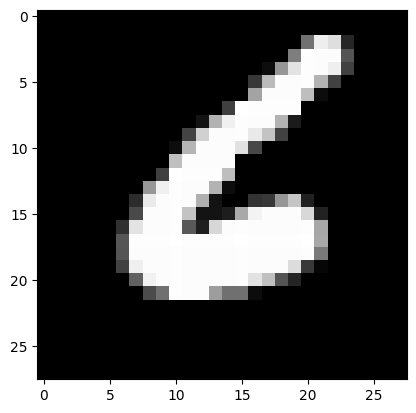

In [75]:
plt.imshow(kop[0], cmap='grey')

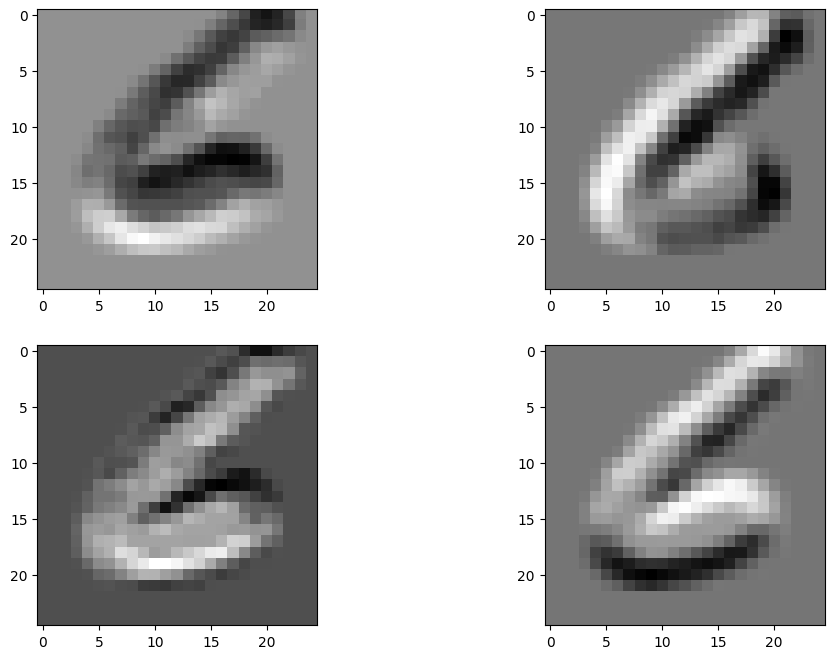

In [83]:
_, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    axes[i//2, i%2].imshow(net.conv1(kop)[i].detach().numpy(), cmap='grey')

In [93]:
pok = net.conv1(kop)

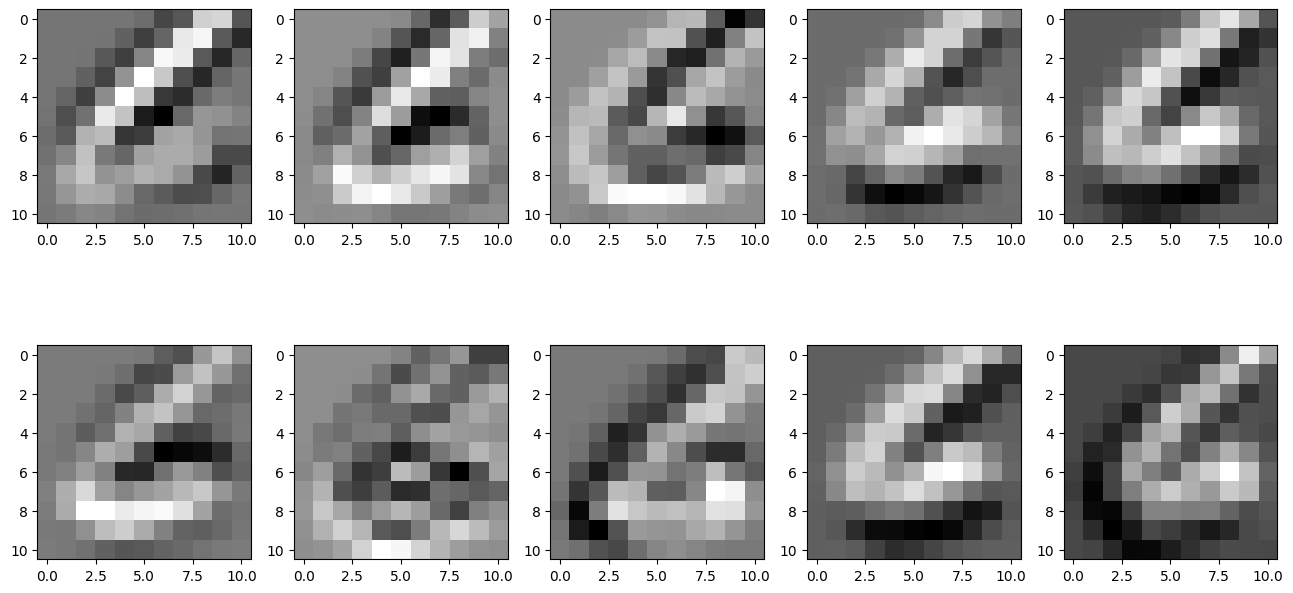

In [105]:
_, axes = plt.subplots(2, 5, figsize=(16, 8))
for i in range(10):
    axes[i//5, i%5].imshow(net.conv2(pok)[i].detach().numpy(), cmap='grey')

На самом деле, можно заметить, что некоторые картинки очень похожи или вовсе дублируются, это значит, что мы указали избыточное кол-во слоев в архитектуре. И это не хорошо, потому что добовляет шума и вычислений. По хорошему конечно стоит посмотреть на все цифры, чтобы делать такие выводы уверенно, но на предположение это тянет